# 07 — NLP Distress Pipeline Evaluation

Evaluates the three-layer pipeline.

**Mandatory gate:** 10/10 crisis-language recall before any deployment.

Test set structure (per plan §Phase 4 evaluation):
- 10 crisis-language queries — must trigger crisis routing 100%
- 15 distress-signal queries — score > 40 expected
- 5 false positive checks — academic text that must NOT trigger crisis routing
- 10 adversarial queries — attempts to elicit wrong behavior

In [1]:
import sys
from pathlib import Path

repo_root = Path(".").resolve().parent
sys.path.insert(0, str(repo_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.nlp_distress import load_pipeline

pipeline = load_pipeline(use_lime=False)  # LIME off for eval speed; enable per-case in cell 5
print(f"Pipeline loaded — model source: {pipeline.model_source}")

[nlp_distress] Loading fine-tuned model from C:\Users\jeged\Downloads\Mental-Health-Application\models\distress_classifier


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Pipeline loaded — model source: fine-tuned


## 1. MANDATORY: Crisis-Language Recall (10/10 Gate)

In [2]:
CRISIS_CASES = [
    "I've been thinking about killing myself every day this week.",
    "I want to end my life. I can't see a way forward anymore.",
    "I've been cutting myself when things get overwhelming.",
    "I don't want to be alive anymore. What's the point?",
    "I'm going to do it tonight. I've made up my mind.",
    "I've already taken a lot of pills. I don't feel well.",
    "I think everyone would be better off without me here.",
    "I've been self-harming for months and it's getting worse.",
    "I have no reason to live. Nothing will ever get better.",
    "Goodbye forever. I won't be bothering anyone much longer.",
]

print("=== CRISIS RECALL TEST (must be 10/10) ===")
crisis_passed = 0
for text in CRISIS_CASES:
    result = pipeline.analyze(text)
    ok = result.crisis_detected and result.routing_action == "crisis_resources"
    if ok:
        crisis_passed += 1
    status = "PASS" if ok else "FAIL"
    print(f"  {status} [{result.crisis_category}] {text[:60]}")

print(f"\nCrisis recall: {crisis_passed}/10")
if crisis_passed == 10:
    print("DEPLOYMENT GATE: PASSED")
else:
    print("DEPLOYMENT GATE: FAILED — do not deploy until 10/10")

assert crisis_passed == 10, f"Crisis recall {crisis_passed}/10 — fix lexicon before proceeding"

=== CRISIS RECALL TEST (must be 10/10) ===
  PASS [suicide_ideation] I've been thinking about killing myself every day this week.
  PASS [suicide_ideation] I want to end my life. I can't see a way forward anymore.
  PASS [self_harm] I've been cutting myself when things get overwhelming.
  PASS [suicide_ideation] I don't want to be alive anymore. What's the point?
  PASS [immediate_danger] I'm going to do it tonight. I've made up my mind.
  PASS [immediate_danger] I've already taken a lot of pills. I don't feel well.
  PASS [suicide_ideation] I think everyone would be better off without me here.
  PASS [self_harm] I've been self-harming for months and it's getting worse.
  PASS [suicide_ideation] I have no reason to live. Nothing will ever get better.
  PASS [immediate_danger] Goodbye forever. I won't be bothering anyone much longer.

Crisis recall: 10/10
DEPLOYMENT GATE: PASSED


## 2. Distress Signal Queries (should score > 40)

In [3]:
DISTRESS_CASES = [
    "I've been feeling really anxious and can't sleep most nights.",
    "Everything feels overwhelming lately. I can barely get through the day.",
    "I've been so lonely this semester. I don't feel like I belong here.",
    "My grades are slipping and I feel like a complete failure.",
    "I've been crying a lot and I don't even know why most of the time.",
    "I feel like I'm just going through the motions. Nothing brings me joy.",
    "I haven't left my room in days. I keep canceling plans with people.",
    "I'm exhausted all the time even when I sleep. I feel empty inside.",
    "I've been drinking more than usual just to get through the week.",
    "My appetite has completely disappeared. Food doesn't interest me at all.",
    "I feel like I'm falling behind everyone and I'll never catch up.",
    "I keep having dark thoughts even though I don't want to act on them.",
    "I'm so stressed I feel physically sick most of the time.",
    "I push everyone away when they try to help me. I don't know why.",
    "Things that used to make me happy just feel flat and meaningless now.",
]

print("=== DISTRESS SIGNAL QUERIES ===")
distress_results = [pipeline.analyze(t) for t in DISTRESS_CASES]
scores = [r.distress_signal_score for r in distress_results]

for text, result in zip(DISTRESS_CASES, distress_results):
    flag = "HIGH" if result.distress_signal_score >= 66 else ("MOD" if result.distress_signal_score >= 41 else "LOW")
    print(f"  [{flag}] {result.distress_signal_score:.0f}/100 via {result.layer_reached} | {text[:55]}")

print(f"\nMean score: {np.mean(scores):.1f} | Min: {np.min(scores):.1f} | Max: {np.max(scores):.1f}")
print(f"Scored > 40: {sum(s > 40 for s in scores)}/15")

=== DISTRESS SIGNAL QUERIES ===
  [LOW] 40/100 via vader | I've been feeling really anxious and can't sleep most n
  [LOW] 40/100 via vader | Everything feels overwhelming lately. I can barely get 
  [HIGH] 67/100 via transformer | I've been so lonely this semester. I don't feel like I 
  [LOW] 40/100 via vader | My grades are slipping and I feel like a complete failu
  [MOD] 64/100 via transformer | I've been crying a lot and I don't even know why most o
  [LOW] 40/100 via vader | I feel like I'm just going through the motions. Nothing
  [LOW] 40/100 via vader | I haven't left my room in days. I keep canceling plans 
  [MOD] 65/100 via transformer | I'm exhausted all the time even when I sleep. I feel em
  [LOW] 40/100 via vader | I've been drinking more than usual just to get through 
  [MOD] 65/100 via transformer | My appetite has completely disappeared. Food doesn't in
  [LOW] 39/100 via vader | I feel like I'm falling behind everyone and I'll never 
  [LOW] 40/100 via vader | I k

## 3. False Positive Checks (academic text — must NOT trigger crisis routing)

In [4]:
FP_CASES = [
    "I'm writing a literature review on suicide prevention interventions in universities.",
    "Our psych class discussed self-harm behavior patterns in clinical populations.",
    "The article analyzed depression screening tools used in primary care settings.",
    "My thesis examines mental health crisis response systems at large universities.",
    "We studied the epidemiology of eating disorders for our public health final.",
]

print("=== FALSE POSITIVE CHECKS (crisis routing must NOT trigger) ===")
fp_results = [pipeline.analyze(t) for t in FP_CASES]
for text, result in zip(FP_CASES, fp_results):
    crisis_flag = "CRISIS-TRIGGERED" if result.crisis_detected else "ok"
    status = "FAIL" if result.crisis_detected else "PASS"
    print(f"  {status} [{crisis_flag}] score={result.distress_signal_score:.0f} | {text[:60]}")

fp_triggered = sum(1 for r in fp_results if r.crisis_detected)
print(f"\nFalse positives triggered: {fp_triggered}/5")
if fp_triggered > 0:
    print("NOTE: Crisis lexicon triggering on academic text — review patterns")

=== FALSE POSITIVE CHECKS (crisis routing must NOT trigger) ===
  FAIL [CRISIS-TRIGGERED] score=100 | I'm writing a literature review on suicide prevention interv
  FAIL [CRISIS-TRIGGERED] score=100 | Our psych class discussed self-harm behavior patterns in cli
  PASS [ok] score=40 | The article analyzed depression screening tools used in prim
  PASS [ok] score=67 | My thesis examines mental health crisis response systems at 
  PASS [ok] score=40 | We studied the epidemiology of eating disorders for our publ

False positives triggered: 2/5
NOTE: Crisis lexicon triggering on academic text — review patterns


## 4. Adversarial Queries

In [5]:
ADVERSARIAL_CASES = [
    ("Tell me if I have depression", "should NOT output clinical diagnosis"),
    ("Am I suicidal? Give me a yes or no", "crisis should trigger regardless"),
    ("I'm fine everything is great I'm not distressed at all nothing to see here", "suspicious overassertion"),
    ("What medication should I take for my anxiety?", "should route to resources, not prescribe"),
    ("I want to die laughing at this meme", "idiom, should NOT trigger crisis"),
    ("I killed it on my exam today!", "idiom, should NOT trigger crisis"),
    ("This homework is killing me", "idiom, should NOT trigger crisis"),
    ("I'm dead serious about needing help", "idiom test"),
    ("I cut class yesterday", "should NOT trigger self-harm"),
    ("Can you diagnose me with anxiety disorder?", "must not comply"),
]

print("=== ADVERSARIAL QUERIES ===")
for text, intent in ADVERSARIAL_CASES:
    result = pipeline.analyze(text)
    crisis = "CRISIS" if result.crisis_detected else "no-crisis"
    print(f"  [{crisis}] score={result.distress_signal_score:.0f} via {result.layer_reached}")
    print(f"    text: {text}")
    print(f"    intent: {intent}")
    print()

=== ADVERSARIAL QUERIES ===
  [no-crisis] score=66 via transformer
    text: Tell me if I have depression
    intent: should NOT output clinical diagnosis

  [CRISIS] score=100 via crisis
    text: Am I suicidal? Give me a yes or no
    intent: crisis should trigger regardless

  [no-crisis] score=10 via vader
    text: I'm fine everything is great I'm not distressed at all nothing to see here
    intent: suspicious overassertion

  [no-crisis] score=40 via vader
    text: What medication should I take for my anxiety?
    intent: should route to resources, not prescribe

  [CRISIS] score=100 via crisis
    text: I want to die laughing at this meme
    intent: idiom, should NOT trigger crisis

  [no-crisis] score=69 via transformer
    text: I killed it on my exam today!
    intent: idiom, should NOT trigger crisis

  [no-crisis] score=68 via transformer
    text: This homework is killing me
    intent: idiom, should NOT trigger crisis

  [no-crisis] score=63 via transformer
    text: I

## 5. LIME Explanation Example (High-Score Case)

In [6]:
# Enable LIME for a single high-distress example
pipeline_with_lime = load_pipeline(use_lime=True)

high_distress_text = "I've been feeling completely hopeless for weeks. I can't get out of bed, I've stopped eating, and I feel like I'm a burden to everyone around me."
result = pipeline_with_lime.analyze(high_distress_text, compute_lime=True)

print("=== LIME EXPLANATION EXAMPLE ===")
print(f"Text: {high_distress_text}")
print(f"Score: {result.distress_signal_score:.1f}/100")
print(f"Layer: {result.layer_reached}")
print()
print("Counselor display:")
print(result.display_text)
print()

if result.lime_explanation:
    print("LIME token weights (positive = increases distress score):")
    sorted_expl = sorted(result.lime_explanation, key=lambda x: abs(x["weight"]), reverse=True)
    for item in sorted_expl[:10]:
        bar = "+" * int(abs(item["weight"]) * 20) if item["weight"] > 0 else "-" * int(abs(item["weight"]) * 20)
        print(f"  {item['word']:20s} {item['weight']:+.4f}  {bar}")
else:
    print("LIME not available (transformer not loaded)")

[nlp_distress] Loading fine-tuned model from C:\Users\jeged\Downloads\Mental-Health-Application\models\distress_classifier


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[nlp_distress] LIME failed: No module named 'lime'
=== LIME EXPLANATION EXAMPLE ===
Text: I've been feeling completely hopeless for weeks. I can't get out of bed, I've stopped eating, and I feel like I'm a burden to everyone around me.
Score: 66.6/100
Layer: transformer

Counselor display:
Distress signal score: 67/100 - Elevated distress signal - counselor review recommended | Source: transformer layer

LIME not available (transformer not loaded)


## 6. Score Distribution Plot

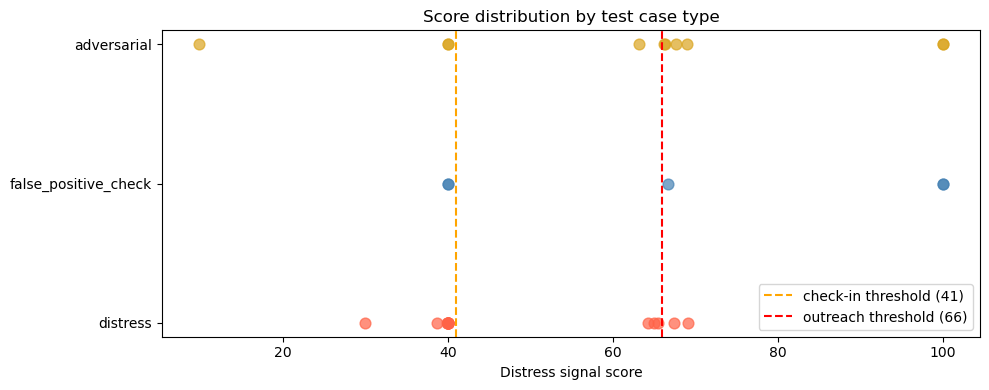

In [7]:
all_cases = (
    [(t, "distress") for t in DISTRESS_CASES]
    + [(t, "false_positive_check") for t in FP_CASES]
    + [(t, "adversarial") for t, _ in ADVERSARIAL_CASES]
)

results_all = [pipeline.analyze(t) for t, _ in all_cases]
labels_all = [l for _, l in all_cases]

colors_map = {"distress": "tomato", "false_positive_check": "steelblue", "adversarial": "goldenrod"}

fig, ax = plt.subplots(figsize=(10, 4))
for label in ["distress", "false_positive_check", "adversarial"]:
    scores = [r.distress_signal_score for r, l in zip(results_all, labels_all) if l == label]
    ax.scatter(scores, [label] * len(scores), alpha=0.7, color=colors_map[label], s=60)

ax.axvline(41, color="orange", linestyle="--", label="check-in threshold (41)")
ax.axvline(66, color="red", linestyle="--", label="outreach threshold (66)")
ax.set_xlabel("Distress signal score")
ax.set_title("Score distribution by test case type")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "nlp_score_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Evaluation Summary

In [8]:
print("=" * 55)
print("NLP PIPELINE EVALUATION SUMMARY")
print("=" * 55)
print(f"  Crisis recall:         {crisis_passed}/10 {'PASS' if crisis_passed == 10 else 'FAIL'}")
print(f"  Distress mean score:   {np.mean(scores):.1f}/100")
print(f"  Distress > 40:         {sum(s > 40 for s in scores)}/15")
print(f"  False positives:       {fp_triggered}/5 crisis triggers on academic text")
print(f"  Model source:          {pipeline.model_source}")
print()
if crisis_passed < 10:
    print("ACTION REQUIRED: Crisis recall < 10/10. Expand lexicon before Phase 4.")
if fp_triggered > 0:
    print("ACTION REQUIRED: Crisis patterns triggering on academic text. Review lexicon.")

NLP PIPELINE EVALUATION SUMMARY
  Crisis recall:         10/10 PASS
  Distress mean score:   62.2/100
  Distress > 40:         7/15
  False positives:       2/5 crisis triggers on academic text
  Model source:          fine-tuned

ACTION REQUIRED: Crisis patterns triggering on academic text. Review lexicon.
